# SPY vs RSP: Divergence & Mean-Reversion Analysis

This notebook analyzes the performance gap between the **cap-weighted S&P 500 (SPY)** and the **equal-weighted S&P 500 (RSP)** from 2007 to present, testing whether extreme divergences between the two indexes mean-revert over time.

---

## Background

The S&P 500 can be tracked two ways:

- **Cap-weighted (SPY):** Each stock's weight is proportional to its market cap. The largest companies like Apple, Microsoft and Nvidia dominate returns. 
- **Equal-weighted (RSP):** Every stock gets the same weight (~0.2%), rebalancing quarterly to maintain equal exposure across all stocks. RSP approximates the return of the average stock in the index.

When a handful of mega-caps drive returns, SPY pulls ahead of RSP. The main question of this project is: **when that gap reaches a statistical extreme, does it mean-revert?**

---

## Hypothesis

> When the performance gap between SPY and RSP reaches a statistically extreme level (rolling Z-score ≤ -2.0, meaning SPY is far ahead of RSP), the divergence will mean-revert and RSP will outperform going forward.

## 1. Imports & Configuration

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import coint
import warnings

warnings.filterwarnings("ignore")

# Configuration
TICKERS     = ["SPY", "RSP"]
START_DATE  = "2007-01-01"
ZSCORE_WIN  = 252    # rolling window for Z-score (~1 trading year)
COINT_WIN   = 756    # rolling cointegration window (~3 years)
EXTREME_Z   = 2.0    # threshold for "statistically extreme"
OUTPUT_FILE = "spy_rsp_analysis.png"

## 2. Fetch Data

We pull daily adjusted closing prices for SPY and RSP from Yahoo Finance. The dataset runs from January 2007 to present, covering the GFC, post-crisis recovery, COVID crash, and the AI-driven mega-cap concentration period.

In [2]:
print("Fetching data from yfinance …")
raw = yf.download(TICKERS, start=START_DATE, auto_adjust=True, progress=False)["Close"]
raw.columns = ["RSP", "SPY"]
prices = raw.dropna()

print(f"  Data range  : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"  Trading days: {len(prices)}")
prices[["SPY", "RSP"]].tail()

Fetching data from yfinance …
  Data range  : 2007-01-03 → 2026-06-11
  Trading days: 4891


,SPY,RSP
Date,,
2026-06-05,737.549988,207.830002
2026-06-08,739.219971,207.610001
2026-06-09,737.049988,209.190002
2026-06-10,725.429993,206.529999
2026-06-11,737.760010,209.750000


## 3. Relative Performance Ratio & Log Spread

We calculate two key metrics:

- **RSP/SPY Ratio:** A direct measure of which index is ahead. When the ratio falls below its historical mean, SPY is dominating.
- **Log Spread:** `log(RSP) - log(SPY)`. Using log prices makes the spread stationary and suitable for Z-score analysis.

In [3]:
prices["Ratio"]   = prices["RSP"] / prices["SPY"]
prices["Log_SPY"] = np.log(prices["SPY"])
prices["Log_RSP"] = np.log(prices["RSP"])
prices["Spread"]  = prices["Log_RSP"] - prices["Log_SPY"]

print(f"Mean RSP/SPY ratio : {prices['Ratio'].mean():.4f}")
print(f"Current RSP/SPY    : {prices['Ratio'].iloc[-1]:.4f}")
print(f"Log spread range   : {prices['Spread'].min():.3f} to {prices['Spread'].max():.3f}")

Mean RSP/SPY ratio : 0.3542
Current RSP/SPY    : 0.2843
Log spread range   : -1.301 to -0.935


## 4. Rolling Z-Score

The Z-score measures how far the current spread deviates from its rolling 1-year mean, normalized by its rolling standard deviation:

$$Z_t = \frac{\text{Spread}_t - \mu_{t}}{\sigma_{t}}$$

A Z-score **≤ -2.0** flags a statistically extreme episode of SPY dominance and is the entry signal for the hypothesis test.

In [4]:
roll_mean = prices["Spread"].rolling(ZSCORE_WIN).mean()
roll_std  = prices["Spread"].rolling(ZSCORE_WIN).std()
prices["ZScore"] = (prices["Spread"] - roll_mean) / roll_std

current_z = prices["ZScore"].iloc[-1]
print(f"Current Z-score : {current_z:+.2f}  "
      f"({'RSP extended above SPY' if current_z > 0 else 'SPY extended above RSP'})")
if abs(current_z) >= EXTREME_Z:
    print(f"  ⚡ Beyond ±{EXTREME_Z} → historically ripe for mean-reversion")
else:
    print(f"  Within ±{EXTREME_Z} → no extreme divergence signal currently")

Current Z-score : -0.29  (SPY extended above RSP)
  Within ±2.0 → no extreme divergence signal currently


## 5. Cointegration Tests

Cointegration tests whether SPY and RSP are bound by a long-run equilibrium aka whether divergences must eventually revert. We run two tests:

1. **Full-period Engle-Granger test**: a single pass/fail over the entire 2007–present dataset
2. **Rolling 3-year window test**: detects whether the relationship is stable or regime-dependent

The rolling test is more informative here because a single test over 19 years spans too many different market structures to give a clean result.

In [5]:
# Full-period test
score, p_value, _ = coint(prices["Log_SPY"], prices["Log_RSP"])
print("Engle-Granger cointegration test (full period)")
print(f"  Test statistic : {score:.4f}")
print(f"  p-value        : {p_value:.4f}")
if p_value < 0.05:
    print("  ✅ Cointegrated (p < 0.05) — long-run relationship confirmed")
else:
    print("  ⚠️  Not cointegrated at 5% — see rolling test below")

print(f"\nComputing rolling cointegration ({COINT_WIN}-day window) …")
roll_p, roll_dates = [], []
for i in range(COINT_WIN, len(prices), 21):
    window = prices.iloc[i - COINT_WIN:i]
    _, p, _ = coint(window["Log_SPY"], window["Log_RSP"])
    roll_p.append(p)
    roll_dates.append(prices.index[i])

roll_coint = pd.Series(roll_p, index=roll_dates)
pct_cointegrated = (roll_coint < 0.05).mean() * 100
print(f"  Cointegrated in {pct_cointegrated:.1f}% of 3-year windows")

Engle-Granger cointegration test (full period)
  Test statistic : -1.4866
  p-value        : 0.7663
  ⚠️  Not cointegrated at 5% — see rolling test below

Computing rolling cointegration (756-day window) …
  Cointegrated in 9.6% of 3-year windows


## 6. Extreme Divergence Episode Count

In [6]:
extreme_low  = prices[prices["ZScore"] <= -EXTREME_Z]
extreme_high = prices[prices["ZScore"] >=  EXTREME_Z]
print(f"Extreme divergence episodes (|Z| ≥ {EXTREME_Z})")
print(f"  SPY dominant  (Z ≤ -{EXTREME_Z}): {len(extreme_low):>4d} days")
print(f"  RSP dominant  (Z ≥ +{EXTREME_Z}): {len(extreme_high):>4d} days")
print(f"\nAsymmetry ratio: {len(extreme_low) / len(extreme_high):.1f}x more SPY-dominant days")

Extreme divergence episodes (|Z| ≥ 2.0)
  SPY dominant  (Z ≤ -2.0):  515 days
  RSP dominant  (Z ≥ +2.0):  152 days

Asymmetry ratio: 3.4x more SPY-dominant days


## 7. Five-Panel Chart

The chart shows:
1. Indexed total returns (SPY vs RSP, base = 100)
2. RSP/SPY ratio over time
3. Rolling Z-score with ±2σ thresholds highlighted
4. Rolling 3-year cointegration p-value
5. Summary statistics

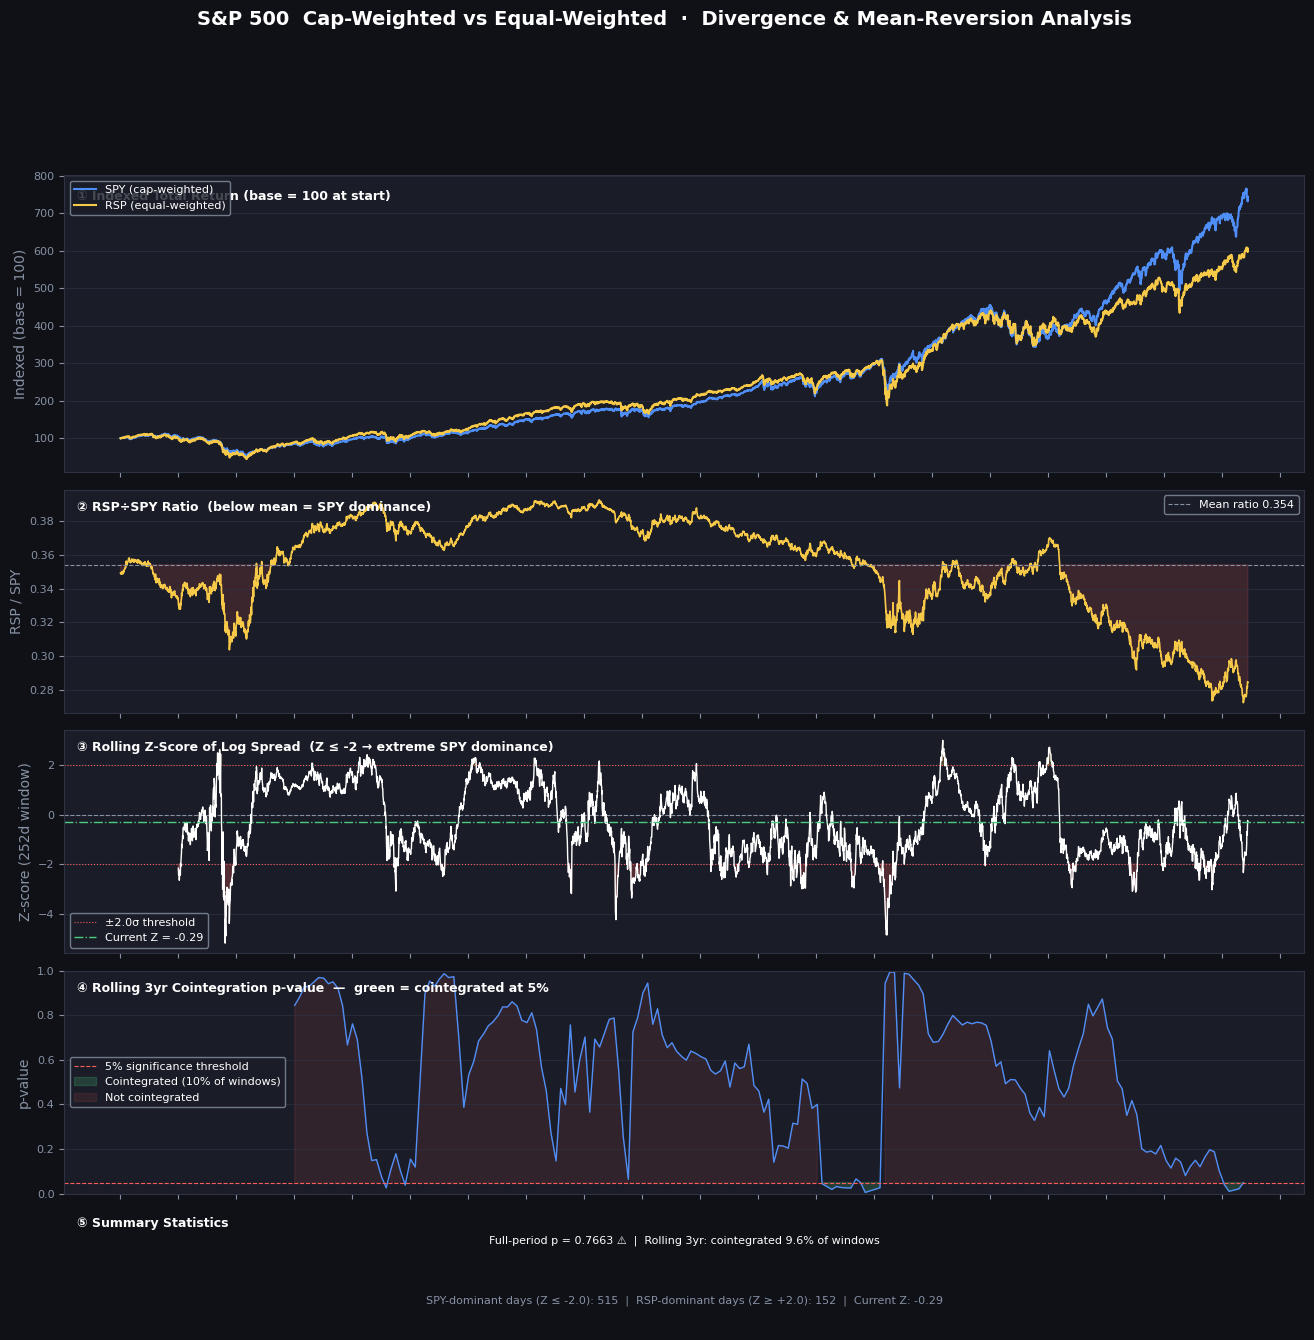

Chart saved → spy_rsp_analysis.png


In [7]:
FG    = "#0f1117"
PANEL = "#1a1d27"
SPY_C = "#4f8ef7"
RSP_C = "#f7c948"
WARN  = "#ff5c5c"
NEUT  = "#8892a4"
GREEN = "#4fc97e"

fig = plt.figure(figsize=(16, 15), facecolor=FG)
fig.suptitle(
    "S&P 500  Cap-Weighted vs Equal-Weighted  ·  Divergence & Mean-Reversion Analysis",
    color="white", fontsize=14, fontweight="bold", y=0.99
)

axes = fig.subplots(5, 1, sharex=True,
                    gridspec_kw={"hspace": 0.08,
                                 "height_ratios": [2, 1.5, 1.5, 1.5, 0.8]})

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=NEUT, labelsize=8)
    ax.yaxis.label.set_color(NEUT)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2e3242")

def panel_label(ax, text):
    ax.text(0.01, 0.95, text, transform=ax.transAxes,
            color="white", fontsize=9, fontweight="bold", va="top")

# Indexed price levels
ax = axes[0]
spy_idx = prices["SPY"] / prices["SPY"].iloc[0] * 100
rsp_idx = prices["RSP"] / prices["RSP"].iloc[0] * 100
ax.plot(prices.index, spy_idx, color=SPY_C, lw=1.5, label="SPY (cap-weighted)")
ax.plot(prices.index, rsp_idx, color=RSP_C, lw=1.5, label="RSP (equal-weighted)")
ax.set_ylabel("Indexed (base = 100)")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=NEUT, labelcolor="white", loc="upper left")
panel_label(ax, "① Indexed Total Return (base = 100 at start)")
ax.grid(axis="y", color="#2e3242", lw=0.5)

# RSP/SPY ratio
ax = axes[1]
ratio_mean = prices["Ratio"].mean()
ax.plot(prices.index, prices["Ratio"], color=RSP_C, lw=1.2)
ax.axhline(ratio_mean, color=NEUT, lw=0.8, ls="--", label=f"Mean ratio {ratio_mean:.3f}")
ax.fill_between(prices.index, prices["Ratio"], ratio_mean,
                where=(prices["Ratio"] < ratio_mean), color=WARN, alpha=0.15)
ax.set_ylabel("RSP / SPY")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=NEUT, labelcolor="white")
panel_label(ax, "② RSP÷SPY Ratio  (below mean = SPY dominance)")
ax.grid(axis="y", color="#2e3242", lw=0.5)

# Rolling Z-score
ax = axes[2]
ax.axhline(0,          color=NEUT, lw=0.8, ls="--")
ax.axhline( EXTREME_Z, color=WARN, lw=0.8, ls=":", label=f"±{EXTREME_Z}σ threshold")
ax.axhline(-EXTREME_Z, color=WARN, lw=0.8, ls=":")
ax.fill_between(prices.index, prices["ZScore"],  EXTREME_Z,
                where=(prices["ZScore"] >=  EXTREME_Z), color=RSP_C, alpha=0.25)
ax.fill_between(prices.index, prices["ZScore"], -EXTREME_Z,
                where=(prices["ZScore"] <= -EXTREME_Z), color=WARN, alpha=0.25)
ax.plot(prices.index, prices["ZScore"], color="white", lw=1.0)
ax.axhline(current_z, color=GREEN, lw=1, ls="-.",
           label=f"Current Z = {current_z:+.2f}")
ax.set_ylabel(f"Z-score ({ZSCORE_WIN}d window)")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=NEUT, labelcolor="white")
panel_label(ax, "③ Rolling Z-Score of Log Spread  (Z ≤ -2 → extreme SPY dominance)")
ax.grid(axis="y", color="#2e3242", lw=0.5)

# Rolling cointegration p-value
ax = axes[3]
ax.plot(roll_coint.index, roll_coint.values, color=SPY_C, lw=1.0)
ax.axhline(0.05, color=WARN, lw=0.8, ls="--", label="5% significance threshold")
ax.fill_between(roll_coint.index, roll_coint.values, 0.05,
                where=(roll_coint.values < 0.05), color=GREEN, alpha=0.2,
                label=f"Cointegrated ({pct_cointegrated:.0f}% of windows)")
ax.fill_between(roll_coint.index, roll_coint.values, 0.05,
                where=(roll_coint.values >= 0.05), color=WARN, alpha=0.1,
                label="Not cointegrated")
ax.set_ylabel("p-value")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=NEUT, labelcolor="white")
panel_label(ax, "④ Rolling 3yr Cointegration p-value  —  green = cointegrated at 5%")
ax.grid(axis="y", color="#2e3242", lw=0.5)

# Summary stats
ax = axes[4]
ax.axis("off")
coint_str = (f"Full-period p = {p_value:.4f} ⚠️  |  "
             f"Rolling 3yr: cointegrated {pct_cointegrated:.1f}% of windows")
extreme_str = (f"SPY-dominant days (Z ≤ -{EXTREME_Z}): {len(extreme_low)}  |  "
               f"RSP-dominant days (Z ≥ +{EXTREME_Z}): {len(extreme_high)}  |  "
               f"Current Z: {current_z:+.2f}")
ax.text(0.5, 0.75, coint_str,   ha="center", va="center", color="white",
        fontsize=8, transform=ax.transAxes)
ax.text(0.5, 0.25, extreme_str, ha="center", va="center", color=NEUT,
        fontsize=8, transform=ax.transAxes)
panel_label(ax, "⑤ Summary Statistics")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), color=NEUT, fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(OUTPUT_FILE, dpi=150, bbox_inches="tight", facecolor=FG)
plt.show()
print(f"Chart saved → {OUTPUT_FILE}")

## 8. Forward Return Analysis

For every day the Z-score crossed below -2.0 (a new SPY-dominant episode begins), we measure how SPY and RSP performed over the next 6, 12, and 24 months. The **RSP Edge** (RSP return minus SPY return) is the main metric. A positive edge confirms mean-reversion.

Results are grouped into six historical regimes to test whether mean-reversion is uniform or context-dependent. Full episode-level data is exported to `spy_rsp_episodes.csv`.

In [8]:
holding_periods = {"6M": 126, "12M": 252, "24M": 504}

spy_extreme    = prices["ZScore"] <= -EXTREME_Z
episode_starts = spy_extreme & ~spy_extreme.shift(1).fillna(False)
entry_dates    = prices.index[episode_starts].tolist()

rows = []
for entry in entry_dates:
    entry_idx = prices.index.get_loc(entry)
    row = {"Entry Date": entry.date()}
    for label, days in holding_periods.items():
        exit_idx = entry_idx + days
        if exit_idx < len(prices):
            spy_ret = (prices["SPY"].iloc[exit_idx] / prices["SPY"].iloc[entry_idx] - 1) * 100
            rsp_ret = (prices["RSP"].iloc[exit_idx] / prices["RSP"].iloc[entry_idx] - 1) * 100
            row[f"SPY {label}"] = f"{spy_ret:+.1f}%"
            row[f"RSP {label}"] = f"{rsp_ret:+.1f}%"
            row[f"RSP Edge {label}"] = f"{rsp_ret - spy_ret:+.1f}%"
        else:
            row[f"SPY {label}"] = "N/A"
            row[f"RSP {label}"] = "N/A"
            row[f"RSP Edge {label}"] = "N/A"
    rows.append(row)

results = pd.DataFrame(rows)

# Export full episode data
csv_path = "spy_rsp_episodes.csv"
results.to_csv(csv_path, index=False)
print(f"Full episode data exported → {csv_path}")

Full episode data exported → spy_rsp_episodes.csv


## 9. Regime-Grouped Results Table

In [9]:
results["Year"] = pd.to_datetime(results["Entry Date"]).dt.year
results["Regime"] = results["Year"].apply(lambda y:
    "GFC Recovery"           if y <= 2010 else
    "Post-Crisis Broadening" if y <= 2013 else
    "Mega-Cap Buildup"       if y <= 2018 else
    "COVID Crash/Recovery"   if y <= 2020 else
    "AI Concentration"       if y <= 2023 else
    "Recent")

for label in ["6M", "12M", "24M"]:
    col = f"RSP Edge {label}"
    results[col] = pd.to_numeric(results[col].str.replace("%", ""), errors="coerce")

regime_order = ["GFC Recovery", "Post-Crisis Broadening", "Mega-Cap Buildup",
                "COVID Crash/Recovery", "AI Concentration", "Recent"]

# Build DataFrame
regime_rows = []
for regime in regime_order:
    group = results[results["Regime"] == regime]
    if group.empty:
        continue
    regime_rows.append({
        "Regime":        regime,
        "Signal Days":   len(group),
        "RSP Edge 6M":   f"{group['RSP Edge 6M'].mean():+.1f}%",
        "RSP Edge 12M":  f"{group['RSP Edge 12M'].mean():+.1f}%",
        "RSP Edge 24M":  f"{group['RSP Edge 24M'].mean():+.1f}%",
    })

avg_e6  = results["RSP Edge 6M"].mean()
avg_e12 = results["RSP Edge 12M"].mean()
avg_e24 = results["RSP Edge 24M"].mean()
regime_rows.append({
    "Regime":       "OVERALL",
    "Signal Days":  len(results),
    "RSP Edge 6M":  f"{avg_e6:+.1f}%",
    "RSP Edge 12M": f"{avg_e12:+.1f}%",
    "RSP Edge 24M": f"{avg_e24:+.1f}%",
})

regime_df = pd.DataFrame(regime_rows).set_index("Regime")
display(regime_df)

hypothesis_confirmed = avg_e6 > 0 and avg_e12 > 0 and avg_e24 > 0
print(f"\nHypothesis {'SUPPORTED ✅' if hypothesis_confirmed else 'PARTIALLY SUPPORTED / MIXED ⚠️'} "
      f"— after extreme SPY dominance (Z ≤ -2), RSP "
      f"{'outperformed across all horizons' if hypothesis_confirmed else 'showed mixed results across horizons'}")

,Signal Days,RSP Edge 6M,RSP Edge 12M,RSP Edge 24M
Regime,,,,
GFC Recovery,60,+8.7%,+13.8%,+25.4%
Post-Crisis Broadening,32,+3.2%,+4.1%,+9.0%
Mega-Cap Buildup,200,+0.4%,-0.3%,-5.6%
COVID Crash/Recovery,98,-2.9%,+4.0%,+5.6%
AI Concentration,31,-3.7%,-9.7%,-15.8%
Recent,94,+0.9%,-2.5%,-12.1%
OVERALL,515,+0.7%,+2.0%,+1.7%



Hypothesis SUPPORTED ✅ — after extreme SPY dominance (Z ≤ -2), RSP outperformed across all horizons


## Conclusion

The hypothesis is **supported on average.** RSP outperformed SPY by **+2.0% at 12 months** and **+1.7% at 24 months** across all 515 signal days. However, the regime table shows the outcome depended on why the divergence happened, not just how large it was.

**It worked best after market crashes.** After the 2008 financial crisis, RSP beat SPY by **+13.8% over the next year** and **+25.4% over two years.** After the COVID crash, RSP beat SPY by **+4.0% at 12 months.** In both cases, the market had sold off broadly, and when it recovered, smaller and mid-size stocks bounced back harder than the mega-caps.

**It failed when mega-caps were genuinely dominant.** Between 2014 and 2018, when tech stocks were steadily taking over the market, the signal fired 200 times and RSP still underperformed by **-5.6% over two years.** During the AI boom from 2021 to 2023, when Nvidia, Microsoft, and Meta were driving the entire market, RSP underperformed by **-15.8% over two years.** 

**The Z-score alone is not enough.** A Z-score of -2.0 looks identical whether SPY is ahead because of a temporary panic or because a handful of companies are earning extraordinary returns. Those two situations have opposite outcomes for RSP. To use this signal in practice, you need a second indicator such as market breadth, sector rotation trends, or Fed policy stance.

> *Extreme divergences between SPY and RSP do mean-revert on average, but the signal is regime-dependent, not unconditional. The Z-score only captures the magnitude of divergence.*

---

### Caveats

- **The statistical test for mean-reversion did not pass.** The Engle-Granger cointegration test failed (p = 0.77), and the rolling version found a stable relationship in only 9.6% of three-year windows. Mean-reversion is not a certianty.
- **The 515 signal days are not 515 independent events.** Many of the signal days are within the same episode (ex: 60 consecutive days during the GFC all count separately). The regime table helps groups these days, but the true sample size is smaller than it appears.
- **Trading costs are not included.** RSP rebalances every quarter to maintain equal weights, generating more transaction costs than SPY. A real strategy would earn somewhat less than the RSP Edge numbers suggest.
- **Recent results are incomplete.** Signal days from 2024 onward do not yet have full 12 and 24 month forward returns, so the Recent regime numbers will change as more data comes in.